Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7385 entries, 0 to 7384
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Make                              7385 non-null   object 
 1   Model                             7385 non-null   object 
 2   Vehicle Class                     7385 non-null   object 
 3   Engine Size(L)                    7385 non-null   float64
 4   Cylinders                         7385 non-null   int64  
 5   Transmission                      7385 non-null   object 
 6   Fuel Type                         7385 non-null   object 
 7   Fuel Consumption City (L/100 km)  7385 non-null   float64
 8   Fuel Consumption Hwy (L/100 km)   7385 non-null   float64
 9   Fuel Consumption Comb (L/100 km)  7385 non-null   float64
 10  Fuel Consumption Comb (mpg)       7385 non-null   int64  
 11  CO2 Emissions(g/km)               7385 non-null 

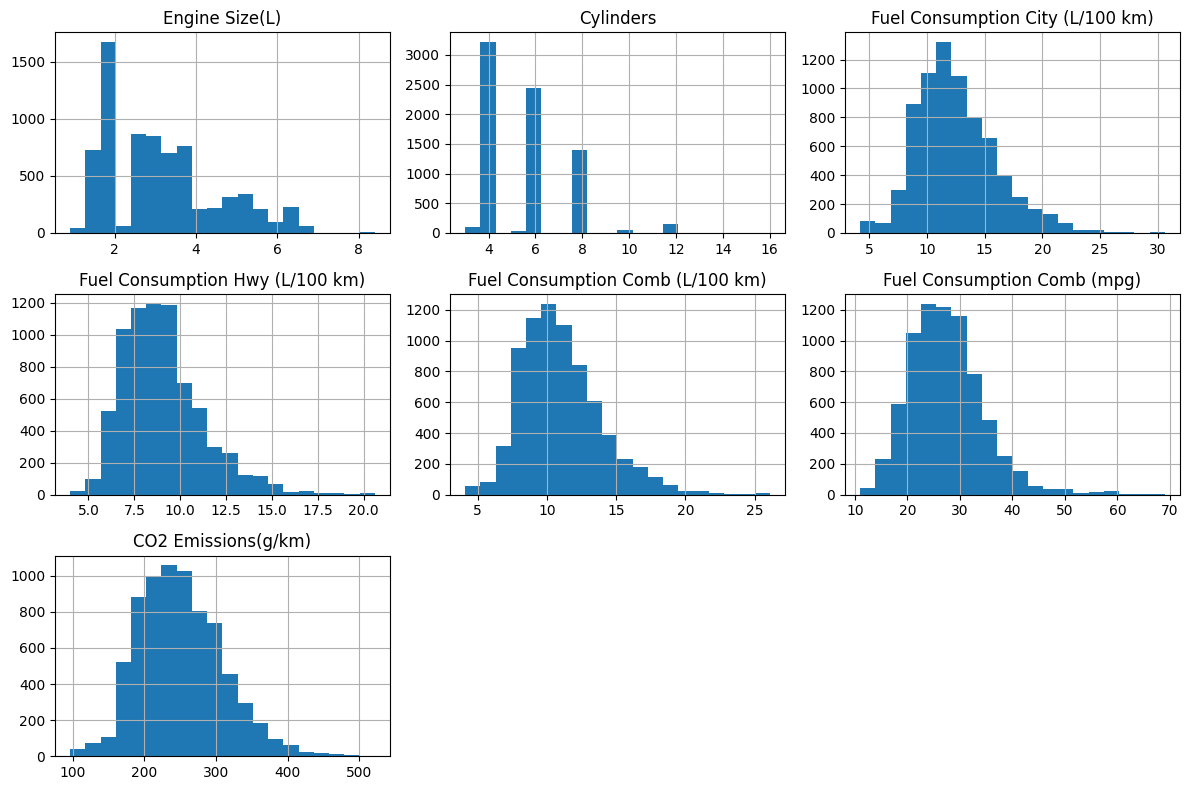


Correlation matrix:
                                  Engine Size(L)  Cylinders  \
Engine Size(L)                          1.000000   0.927653   
Cylinders                               0.927653   1.000000   
Fuel Consumption City (L/100 km)        0.831379   0.800702   
Fuel Consumption Hwy (L/100 km)         0.761526   0.715252   
Fuel Consumption Comb (L/100 km)        0.817060   0.780534   
Fuel Consumption Comb (mpg)            -0.757854  -0.719321   
CO2 Emissions(g/km)                     0.851145   0.832644   

                                  Fuel Consumption City (L/100 km)  \
Engine Size(L)                                            0.831379   
Cylinders                                                 0.800702   
Fuel Consumption City (L/100 km)                          1.000000   
Fuel Consumption Hwy (L/100 km)                           0.948180   
Fuel Consumption Comb (L/100 km)                          0.993810   
Fuel Consumption Comb (mpg)                           

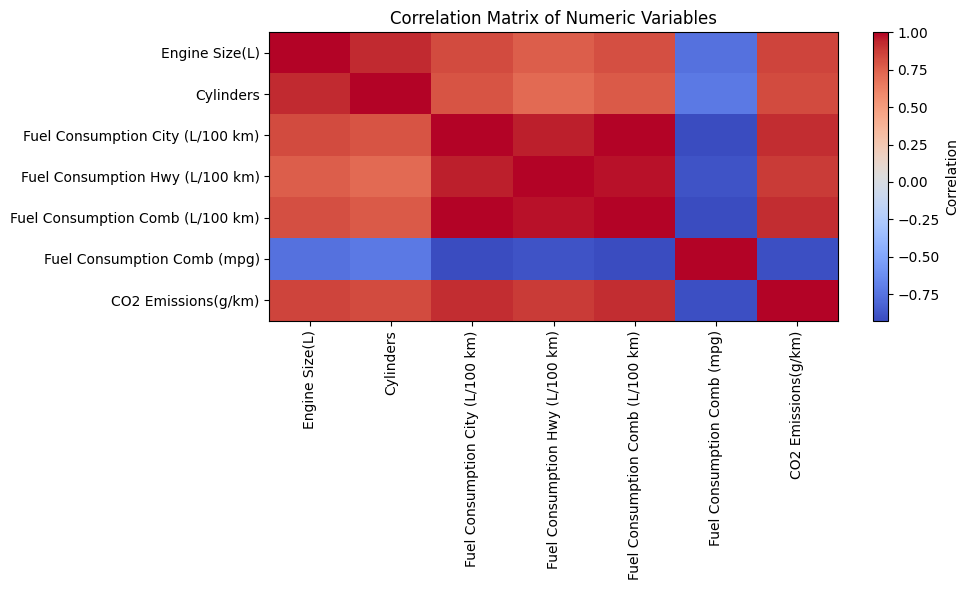

In [6]:

# 1. Dataset information
print("Dataset information:")
df.info()

# 2. Summary statistics
print("\nSummary statistics:")
print(df.describe(include="all"))

# 3. Missing values
print("\nMissing values in each column:")
print(df.isnull().sum())

# 4. Duplicate rows
print("\nNumber of duplicate rows:", df.duplicated().sum())

# 5. Histograms of numeric columns
df.hist(figsize=(12, 8), bins=20)
plt.tight_layout()
plt.show()

# 6. Correlation between numeric columns
numeric_df = df.select_dtypes(include=np.number)

if numeric_df.shape[1] > 1:
    print("\nCorrelation matrix:")
    print(numeric_df.corr())

    plt.figure(figsize=(10, 6))
    plt.imshow(numeric_df.corr(), cmap="coolwarm", aspect="auto")
    plt.colorbar(label="Correlation")
    plt.xticks(range(len(numeric_df.columns)),
               numeric_df.columns, rotation=90)
    plt.yticks(range(len(numeric_df.columns)),
               numeric_df.columns)
    plt.title("Correlation Matrix of Numeric Variables")
    plt.tight_layout()
    plt.show()

In [7]:

# Select the columns needed for regression
data = df[["Engine Size(L)", "CO2 Emissions(g/km)"]].copy()
data = data.dropna()

X = data["Engine Size(L)"].to_numpy(dtype=float)
y = data["CO2 Emissions(g/km)"].to_numpy(dtype=float)

print("Number of vehicles:", len(data))
print("Input feature: Engine Size(L)")
print("Target: CO2 Emissions(g/km)")
print("Preparation complete!")

Number of vehicles: 7385
Input feature: Engine Size(L)
Target: CO2 Emissions(g/km)
Preparation complete!


In [8]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load the CO2 dataset
df = pd.read_csv("CO2.csv")  # Replace with your exact filename

print("Dataset shape:", df.shape)
print("\nFirst five rows:")
print(df.head())

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

Dataset shape: (7385, 12)

First five rows:
    Make       Model Vehicle Class  Engine Size(L)  Cylinders Transmission  \
0  ACURA         ILX       COMPACT             2.0          4          AS5   
1  ACURA         ILX       COMPACT             2.4          4           M6   
2  ACURA  ILX HYBRID       COMPACT             1.5          4          AV7   
3  ACURA     MDX 4WD   SUV - SMALL             3.5          6          AS6   
4  ACURA     RDX AWD   SUV - SMALL             3.5          6          AS6   

  Fuel Type  Fuel Consumption City (L/100 km)  \
0         Z                               9.9   
1         Z                              11.2   
2         Z                               6.0   
3         Z                              12.7   
4         Z                              12.1   

   Fuel Consumption Hwy (L/100 km)  Fuel Consumption Comb (L/100 km)  \
0                              6.7                               8.5   
1                              7.7              

Intercept: 134.52249370749982
Slope: 36.722361203269
MSE: 958.542171681436
RMSE: 30.9603322282148
R-squared: 0.7305252261577988


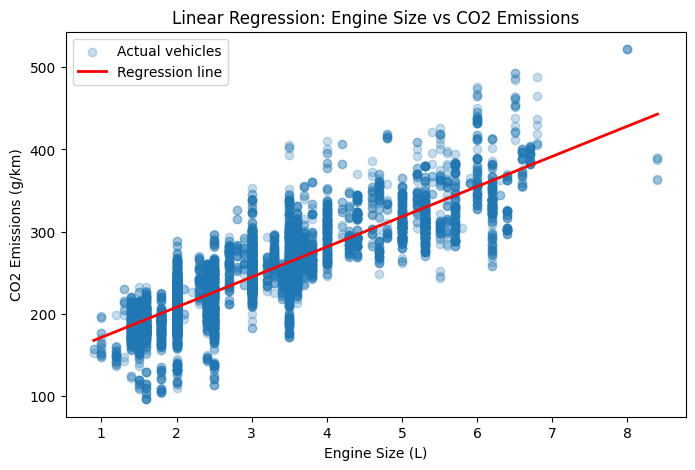

In [9]:

# Split data into training and testing sets
np.random.seed(42)
indices = np.random.permutation(len(X))
split = int(0.8 * len(X))

train_idx = indices[:split]
test_idx = indices[split:]

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

# Train linear regression using least squares
A = np.column_stack((np.ones(len(X_train)), X_train))
b0, b1 = np.linalg.lstsq(A, y_train, rcond=None)[0]

# Make predictions
y_pred = b0 + b1 * X_test

# Evaluate model
mse = np.mean((y_test - y_pred) ** 2)
rmse = np.sqrt(mse)
ss_total = np.sum((y_test - np.mean(y_test)) ** 2)
r2 = 1 - np.sum((y_test - y_pred) ** 2) / ss_total

print("Intercept:", b0)
print("Slope:", b1)
print("MSE:", mse)
print("RMSE:", rmse)
print("R-squared:", r2)

# Visualize the regression line
order = np.argsort(X)
plt.figure(figsize=(8, 5))
plt.scatter(X, y, alpha=0.25, label="Actual vehicles")
plt.plot(X[order], b0 + b1 * X[order],
         color="red", linewidth=2, label="Regression line")
plt.xlabel("Engine Size (L)")
plt.ylabel("CO2 Emissions (g/km)")
plt.title("Linear Regression: Engine Size vs CO2 Emissions")
plt.legend()
plt.show()

CO2 threshold: 246.0 g/km
Intercept: 0.5029275282114178
Coefficient: 3.5757850727007416
Test accuracy: 86.26 %


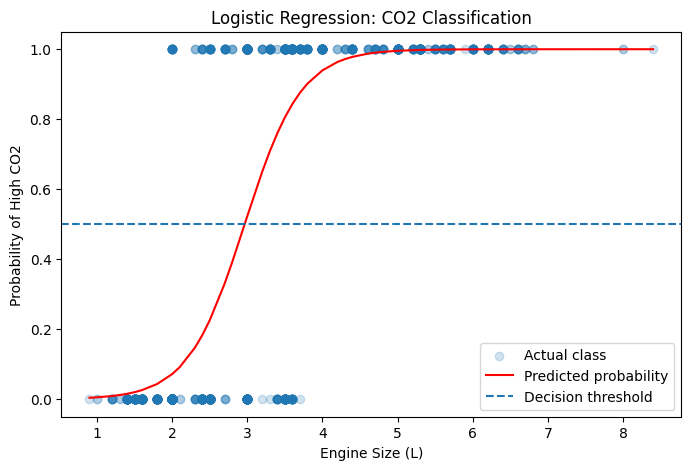

In [10]:

# Create binary labels using the training median
threshold = np.median(y_train)

y_train_bin = (y_train > threshold).astype(float)
y_test_bin = (y_test > threshold).astype(float)

print("CO2 threshold:", threshold, "g/km")

# Standardize engine size using training statistics
x_mean = np.mean(X_train)
x_std = np.std(X_train)

X_train_scaled = (X_train - x_mean) / x_std
X_test_scaled = (X_test - x_mean) / x_std

# Add intercept column
A_train = np.column_stack((np.ones(len(X_train)), X_train_scaled))
A_test = np.column_stack((np.ones(len(X_test)), X_test_scaled))

# Sigmoid function
def sigmoid(z):
    z = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z))

# Initialize model parameters
weights = np.zeros(2)
learning_rate = 0.05
epochs = 3000
n = len(y_train_bin)

# Train with gradient descent
for epoch in range(epochs):
    probabilities = sigmoid(A_train @ weights)
    gradient = A_train.T @ (probabilities - y_train_bin) / n
    weights -= learning_rate * gradient

# Predict on test data
test_probabilities = sigmoid(A_test @ weights)
predictions = (test_probabilities >= 0.5).astype(int)

accuracy = np.mean(predictions == y_test_bin)

print("Intercept:", weights[0])
print("Coefficient:", weights[1])
print("Test accuracy:", round(accuracy * 100, 2), "%")

# Plot predicted probabilities
order = np.argsort(X_test)

plt.figure(figsize=(8, 5))
plt.scatter(X_test, y_test_bin, alpha=0.2, label="Actual class")
plt.plot(X_test[order], test_probabilities[order],
         color="red", label="Predicted probability")
plt.axhline(0.5, linestyle="--", label="Decision threshold")
plt.xlabel("Engine Size (L)")
plt.ylabel("Probability of High CO2")
plt.title("Logistic Regression: CO2 Classification")
plt.legend()
plt.show()